# RQ1 — Performance vs Baselines  
## Final Kaggle Notebook — No Full Train Split + Clean Trust-RAG Answering

This notebook is the corrected final RQ1 file.

Key fixes:
- Streams `squad_v2` validation examples instead of generating the full train split.
- Uses clean Trust-RAG prompt.
- Removes `insufficient evidence` instruction from RQ1.
- Uses `TOP_K_TRUST_CONTEXT = 5`.
- Saves RQ1 figures as PDFs and tables as CSVs.


In [13]:
import os, shutil, glob

for folder in ["/kaggle/working/figures", "/kaggle/working/tables"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

for pattern in [
    "/kaggle/working/*.csv",
    "/kaggle/working/*.pdf",
    "/kaggle/working/figures/*.pdf",
    "/kaggle/working/tables/*.csv"
]:
    for f in glob.glob(pattern):
        try:
            os.remove(f)
        except:
            pass

print("✅ Old RQ1 output files cleared.")

✅ Old RQ1 output files cleared.


Device: cuda
Sample size: 1000
Dataset: squad_v2 validation
Generator: google/flan-t5-small
Figures: /kaggle/working/figures
Tables: /kaggle/working/tables


Streaming SQuAD v2: 0it [00:00, ?it/s]

Loaded answerable examples: 1000
Extra contexts collected: 1993
Sample example: {'id': '56ddde6b9a695914005b9628', 'question': 'In what country is Normandy located?', 'context': 'The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries.', 'answers': ['France', 'France', 'France', 'France']}
Corpus size: 235
First 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generation completed.
Vanilla time: 23.19 seconds
RAG time: 33.6 seconds
Trust-RAG time: 50.28 seconds


,model,EM_pct,F1_pct,Correct_pct,Unsupported_pct,Hallucinated_pct,Latency_sec_total,Latency_sec_per_query
0,LLM,0.7,7.038433,2.1,68.7,29.2,23.187520,0.023188
1,RAG,37.9,51.061672,49.8,43.1,7.1,33.599158,0.033599
2,Trust-RAG,40.2,53.388659,51.6,44.0,4.4,50.282230,0.050282


,id,model,question,gold_answers,prediction,exact_match,f1,response_type
0,56ddde6b9a695914005b9628,LLM,In what country is Normandy located?,France | France | France | France,Normandy,0,0.000000,Unsupported
1,56ddde6b9a695914005b9629,LLM,When were the Normans in Normandy?,10th and 11th centuries | in the 10th and 11th...,Normans in Normandy,0,0.222222,Unsupported
2,56ddde6b9a695914005b962a,LLM,From which countries did the Norse originate?,"Denmark, Iceland and Norway | Denmark, Iceland...",Norsia,0,0.000000,Hallucinated
3,56ddde6b9a695914005b962b,LLM,Who was the Norse leader?,Rollo | Rollo | Rollo | Rollo,Norse emperor,0,0.000000,Unsupported
4,56ddde6b9a695914005b962c,LLM,What century did the Normans first gain their ...,10th century | the first half of the 10th cent...,17th century,0,0.500000,Unsupported
5,56dddf4066d3e219004dad5f,LLM,Who was the duke in the battle of Hastings?,William the Conqueror | William the Conqueror ...,edward ii,0,0.000000,Unsupported
6,56dddf4066d3e219004dad60,LLM,Who ruled the duchy of Normandy,Richard I | Richard I | Richard I,Normandy,0,0.000000,Unsupported
7,56dddf4066d3e219004dad61,LLM,What religion were the Normans,Catholic | Catholic orthodoxy | Catholic,christian,0,0.000000,Unsupported
8,56dde0379a695914005b9636,LLM,What is the original meaning of the word Norman?,"Viking | Norseman, Viking | Norseman, Viking",a symbiosis is a symbiosis,0,0.000000,Unsupported
9,56dde0379a695914005b9637,LLM,When was the Latin version of the word Norman ...,9th century | 9th century | 9th century,in the early 20th equinox,0,0.000000,Unsupported


Saved: /kaggle/working/tables/rq1_table_1_1_quantitative_performance_metrics.csv
Saved: /kaggle/working/tables/rq1_all_model_predictions.csv


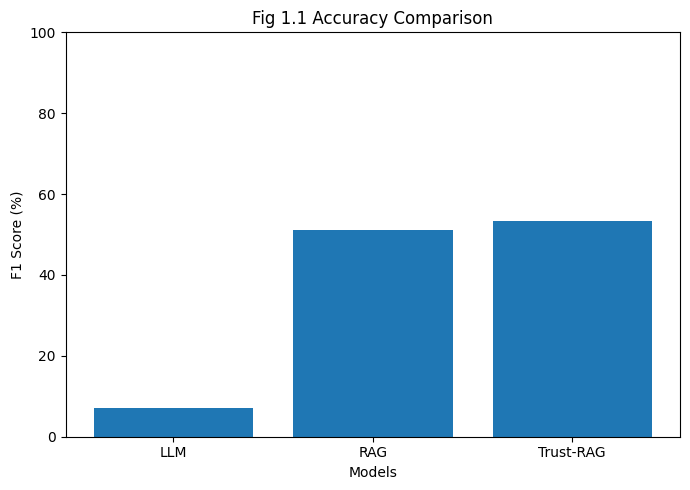

Saved: /kaggle/working/figures/rq1_fig_1_1_accuracy_comparison.pdf


,model,Correct,Unsupported,Hallucinated
0,LLM,2.1,68.7,29.2
1,RAG,49.8,43.1,7.1
2,Trust-RAG,51.6,44.0,4.4


Saved: /kaggle/working/tables/rq1_response_type_distribution.csv


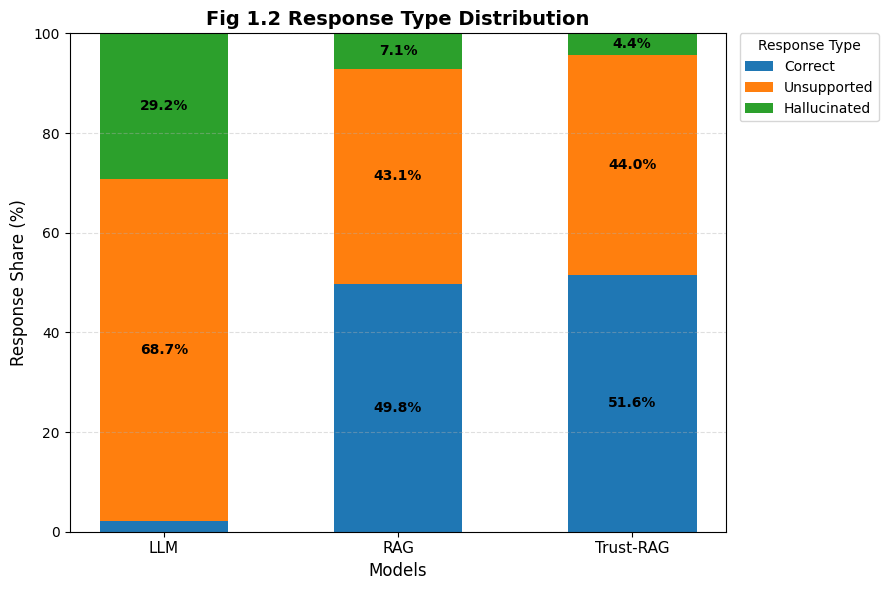

Saved: /kaggle/working/figures/rq1_fig_1_2_response_type_distribution.pdf


,Model,EM (%),F1 (%),Hallucination (%),Unsupported (%),Correct (%),Latency per Query (sec)
0,LLM,0.7,7.038433,29.2,68.7,2.1,0.023188
1,RAG,37.9,51.061672,7.1,43.1,49.8,0.033599
2,Trust-RAG,40.2,53.388659,4.4,44.0,51.6,0.050282


Saved: /kaggle/working/tables/rq1_table_1_1_quantitative_performance_metrics_clean.csv


,Question,Gold Answer,LLM Output,RAG Output,Trust-RAG Output
0,In what country is Normandy located?,France | France | France | France,Normandy,Newfoundland and Labrador,France
1,What century did the Normans first gain their ...,10th century | the first half of the 10th cent...,17th century,first half of the 10th,10th
2,When did the Normans attack Dyrrachium?,1185 | in 1185 | 1185,During World War II the Normans attacked Dyrra...,the first half of,1185
3,Who was the hostage?,Duncan | Duncan | Duncan,he was a hostage in sydney,Guy de Lusignan,Duncan
4,What ruined Richard's plans to reach Acre?,a storm | a storm | a storm,Richard's plans to reach Acre,his troops being led by Guy de Lusignan,a storm


Saved: /kaggle/working/tables/rq1_fig_1_3_qualitative_example_outputs.csv


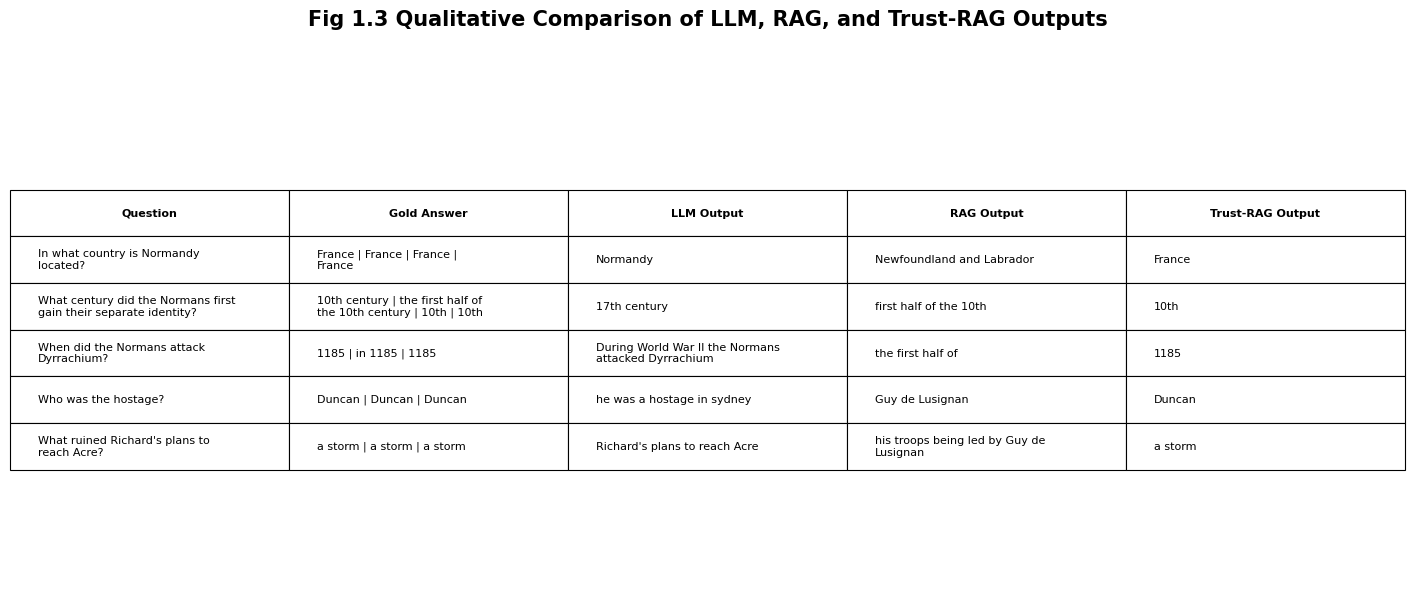

Saved: /kaggle/working/figures/rq1_fig_1_3_qualitative_example_outputs.pdf
=== RQ1 Final Summary ===


,Model,EM (%),F1 (%),Hallucination (%),Unsupported (%),Correct (%),Latency per Query (sec)
0,LLM,0.7,7.038433,29.2,68.7,2.1,0.023188
1,RAG,37.9,51.061672,7.1,43.1,49.8,0.033599
2,Trust-RAG,40.2,53.388659,4.4,44.0,51.6,0.050282


\nSanity check:
RAG F1: 51.06
Trust-RAG F1: 53.39
RAG hallucination: 7.1
Trust-RAG hallucination: 4.4
\nStrong result: Trust-RAG improves F1 and reduces hallucination.
\nGenerated figures:
- rq1_fig_1_1_accuracy_comparison.pdf
- rq1_fig_1_2_response_type_distribution.pdf
- rq1_fig_1_3_qualitative_example_outputs.pdf
\nGenerated tables:
- rq1_all_model_predictions.csv
- rq1_fig_1_3_qualitative_example_outputs.csv
- rq1_response_type_distribution.csv
- rq1_table_1_1_quantitative_performance_metrics.csv
- rq1_table_1_1_quantitative_performance_metrics_clean.csv


In [14]:

# ============================================================
# RQ1 — PERFORMANCE VS BASELINES
# FINAL VERSION
# Streaming loading + clean Trust-RAG prompt, no RQ1 abstention
# ============================================================

!pip install -q --no-cache-dir datasets sentence-transformers transformers faiss-cpu accelerate evaluate

import os, re, time, random, warnings
from collections import Counter
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset

import torch
import faiss
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging
logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ============================================================
# CONFIGURATION
# ============================================================

SAMPLE_SIZE = 1000
# For quick debugging: SAMPLE_SIZE = 50

DATASET_NAME = "squad_v2"
DATASET_SPLIT = "validation"

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
GENERATION_MODEL_NAME = "google/flan-t5-small"
# Stronger but slower option:
# GENERATION_MODEL_NAME = "google/flan-t5-base"

TOP_K_STANDARD_RAG = 3
TOP_K_TRUST_RETRIEVAL = 5
TOP_K_TRUST_CONTEXT = 5

MAX_NEW_TOKENS = 24
BATCH_SIZE_GENERATION = 16

OUTPUT_BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
FIG_DIR = os.path.join(OUTPUT_BASE, "figures")
TABLE_DIR = os.path.join(OUTPUT_BASE, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("Sample size:", SAMPLE_SIZE)
print("Dataset:", DATASET_NAME, DATASET_SPLIT)
print("Generator:", GENERATION_MODEL_NAME)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def short_text(text, max_chars=700):
    text = str(text).replace("\\n", " ")
    text = re.sub(r"\\s+", " ", text).strip()
    return text[:max_chars]

def unique_keep_order(items):
    seen = set()
    out = []
    for x in items:
        x = str(x).strip()
        if len(x) < 50:
            continue
        key = normalize_text(x)[:400]
        if key not in seen:
            seen.add(key)
            out.append(x)
    return out

def is_invalid_answer(answer):
    a = normalize_text(answer)
    if len(a) == 0:
        return True
    invalid_exact = {"evidence", "context", "document", "answer", "question", "unknown", "n a", "none"}
    if a in invalid_exact:
        return True
    if re.fullmatch(r"\\d+", a):
        return True
    bad_patterns = [
        r"^evidence\\s*\\d+",
        r"^document\\s*\\d+",
        r"^context\\s*\\d+",
        r"reliability",
        r"weight",
        r"final answer",
    ]
    return any(re.search(pat, a) for pat in bad_patterns)

def clean_generated_answer(answer):
    answer = str(answer).strip()
    answer = re.sub(
        r"^(answer|final answer|short answer|short final answer)\\s*:\\s*",
        "",
        answer,
        flags=re.I,
    ).strip()
    answer = answer.split("\\n")[0].strip()
    answer = re.sub(r"^[-:]+", "", answer).strip()
    if is_invalid_answer(answer):
        return ""
    return answer

# ============================================================
# DATASET LOADING — STREAMING, NO FULL TRAIN SPLIT
# ============================================================

def load_squad_v2_answerable_stream(sample_size=500, split="validation"):
    ds_stream = load_dataset("squad_v2", split=split, streaming=True)
    examples = []
    extra_contexts = []
    for ex in tqdm(ds_stream, desc="Streaming SQuAD v2"):
        question = ex.get("question", "")
        context = ex.get("context", "")
        answers = ex.get("answers", {}).get("text", [])
        if context:
            extra_contexts.append(context)
        if answers and len(answers) > 0 and str(answers[0]).strip():
            examples.append({
                "id": ex.get("id", f"ex_{len(examples)}"),
                "question": question,
                "context": context,
                "answers": answers,
            })
        if len(examples) >= sample_size:
            break
    return examples, extra_contexts

examples, extra_contexts = load_squad_v2_answerable_stream(SAMPLE_SIZE, DATASET_SPLIT)
print("Loaded answerable examples:", len(examples))
print("Extra contexts collected:", len(extra_contexts))
print("Sample example:", examples[0])

gold_contexts = [ex["context"] for ex in examples]
corpus = unique_keep_order(gold_contexts + extra_contexts)
print("Corpus size:", len(corpus))
print("First context preview:", corpus[0][:500])

# ============================================================
# DENSE RETRIEVAL INDEX
# ============================================================

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

corpus_embeddings = embedding_model.encode(
    corpus,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)

print("FAISS index size:", index.ntotal)
print("Embedding dimension:", dimension)

def retrieve_documents(question, top_k=3):
    q_emb = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")
    scores, idxs = index.search(q_emb, top_k)
    docs = []
    for score, idx in zip(scores[0], idxs[0]):
        docs.append({
            "doc_id": int(idx),
            "score": float(score),
            "text": corpus[int(idx)],
        })
    return docs

def trust_rerank_documents(docs, question):
    """
    Internal adaptive evidence weighting.
    We use the weights only for ranking. They are not shown to the generator.
    """
    q_tokens = set(normalize_text(question).split())
    raw_scores = []
    for d in docs:
        d_tokens = set(normalize_text(d["text"]).split())
        overlap = len(q_tokens & d_tokens) / max(len(q_tokens), 1)
        length_penalty = 1.0 / (1.0 + max(len(d["text"]) - 1200, 0) / 1200)
        score = (0.75 * max(d["score"], 0.0)) + (0.20 * overlap) + (0.05 * length_penalty)
        raw_scores.append(score)
    raw_scores = np.array(raw_scores, dtype=np.float32)
    if raw_scores.sum() <= 0:
        weights = np.ones(len(docs), dtype=np.float32) / max(len(docs), 1)
    else:
        weights = raw_scores / raw_scores.sum()
    reranked = []
    for d, w, s in zip(docs, weights, raw_scores):
        new_d = dict(d)
        new_d["trust_weight"] = float(w)
        new_d["trust_score"] = float(s)
        reranked.append(new_d)
    return sorted(reranked, key=lambda x: x["trust_score"], reverse=True)

test_docs = retrieve_documents(examples[0]["question"], top_k=5)
test_reranked = trust_rerank_documents(test_docs, examples[0]["question"])
print("Question:", examples[0]["question"])
for i, d in enumerate(test_reranked[:5], 1):
    print(f"Rank {i} | retrieval={d['score']:.4f} | trust={d['trust_score']:.4f} | weight={d['trust_weight']:.3f}")
    print(d["text"][:250])

# ============================================================
# GENERATOR
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL_NAME)
generator_model = AutoModelForSeq2SeqLM.from_pretrained(GENERATION_MODEL_NAME).to(DEVICE)
generator_model.eval()
print("Loaded generation model:", GENERATION_MODEL_NAME)

# ============================================================
# FINAL FIXED PROMPTS
# ============================================================

def make_vanilla_prompt(question):
    return (
        "Answer the question with a short factual answer.\\n"
        f"Question: {question}\\n"
        "Short answer:"
    )

def make_standard_rag_prompt(question, docs):
    context = " ".join([short_text(d["text"], 700) for d in docs])
    return (
        "Use the context to answer the question.\\n"
        "Give only the short answer. Do not explain.\\n\\n"
        f"Context: {context}\\n\\n"
        f"Question: {question}\\n"
        "Short answer:"
    )

def make_trust_rag_prompt(question, reranked_docs):
    # Best evidence first, but no evidence labels and no reliability text.
    context = " ".join([
        short_text(d["text"], 700)
        for d in reranked_docs[:TOP_K_TRUST_CONTEXT]
    ])
    return (
        "Use the context below to answer the question.\\n"
        "Give the best short answer supported by the context.\\n"
        "Give only the short final answer. Do not explain.\\n"
        "Do not mention evidence, context, document numbers, or weights.\\n\\n"
        f"Context: {context}\\n\\n"
        f"Question: {question}\\n"
        "Short final answer:"
    )

def batch_generate(prompts, batch_size=16, max_new_tokens=24):
    outputs = []
    for start in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
        batch_prompts = prompts[start:start + batch_size]
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024,
        ).to(DEVICE)
        with torch.no_grad():
            generated = generator_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                do_sample=False,
                early_stopping=True,
            )
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        outputs.extend([clean_generated_answer(x) for x in decoded])
    return outputs

# ============================================================
# RETRIEVAL AND GENERATION
# ============================================================

retrieval_records = []
for ex in tqdm(examples, desc="Retrieving"):
    standard_docs = retrieve_documents(ex["question"], top_k=TOP_K_STANDARD_RAG)
    trust_raw_docs = retrieve_documents(ex["question"], top_k=TOP_K_TRUST_RETRIEVAL)
    trust_docs = trust_rerank_documents(trust_raw_docs, ex["question"])
    retrieval_records.append({
        "id": ex["id"],
        "standard_docs": standard_docs,
        "trust_docs": trust_docs,
        "standard_top_score": standard_docs[0]["score"] if standard_docs else 0.0,
        "trust_top_score": trust_docs[0]["score"] if trust_docs else 0.0,
        "trust_top_weight": trust_docs[0]["trust_weight"] if trust_docs else 0.0,
        "trust_mean_score": float(np.mean([d["score"] for d in trust_docs])) if trust_docs else 0.0,
    })

print("Retrieval completed:", len(retrieval_records))

vanilla_prompts, standard_rag_prompts, trust_rag_prompts = [], [], []
for ex, ret in zip(examples, retrieval_records):
    vanilla_prompts.append(make_vanilla_prompt(ex["question"]))
    standard_rag_prompts.append(make_standard_rag_prompt(ex["question"], ret["standard_docs"]))
    trust_rag_prompts.append(make_trust_rag_prompt(ex["question"], ret["trust_docs"]))

print("Prepared prompts:")
print("Vanilla:", len(vanilla_prompts))
print("RAG:", len(standard_rag_prompts))
print("Trust-RAG:", len(trust_rag_prompts))
print("\\nTrust-RAG prompt preview:")
print(trust_rag_prompts[0][:1200])

start = time.time()
vanilla_answers = batch_generate(vanilla_prompts, BATCH_SIZE_GENERATION, MAX_NEW_TOKENS)
vanilla_time = time.time() - start

start = time.time()
standard_rag_answers = batch_generate(standard_rag_prompts, BATCH_SIZE_GENERATION, MAX_NEW_TOKENS)
standard_rag_time = time.time() - start

start = time.time()
trust_rag_answers = batch_generate(trust_rag_prompts, BATCH_SIZE_GENERATION, MAX_NEW_TOKENS)
trust_rag_time = time.time() - start

print("Generation completed.")
print("Vanilla time:", round(vanilla_time, 2), "seconds")
print("RAG time:", round(standard_rag_time, 2), "seconds")
print("Trust-RAG time:", round(trust_rag_time, 2), "seconds")

# ============================================================
# EVALUATION
# ============================================================

def compute_exact_match(prediction, gold_answers):
    pred = normalize_text(prediction)
    golds = [normalize_text(g) for g in gold_answers]
    return int(pred in golds)

def compute_f1(prediction, gold_answers):
    pred_tokens = normalize_text(prediction).split()
    if len(pred_tokens) == 0:
        return 0.0
    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_text(gold).split()
        if len(gold_tokens) == 0:
            continue
        common = Counter(pred_tokens) & Counter(gold_tokens)
        num_same = sum(common.values())
        if num_same == 0:
            f1 = 0.0
        else:
            precision = num_same / len(pred_tokens)
            recall = num_same / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        best_f1 = max(best_f1, f1)
    return best_f1

def token_overlap_score(answer, evidence):
    ans_tokens = set(normalize_text(answer).split())
    ev_tokens = set(normalize_text(evidence).split())
    if len(ans_tokens) == 0:
        return 0.0
    return len(ans_tokens & ev_tokens) / len(ans_tokens)

def classify_response(prediction, gold_answers, evidence_text):
    pred_norm = normalize_text(prediction)
    f1 = compute_f1(prediction, gold_answers)
    em = compute_exact_match(prediction, gold_answers)
    support = token_overlap_score(prediction, evidence_text)
    if len(pred_norm) == 0:
        return "Unsupported"
    if em == 1 or f1 >= 0.60:
        return "Correct"
    if support >= 0.30:
        return "Unsupported"
    return "Hallucinated"

def evaluate_model(model_name, predictions, evidence_texts, total_time_seconds):
    rows = []
    for ex, pred, evidence in zip(examples, predictions, evidence_texts):
        pred = clean_generated_answer(pred)
        em = compute_exact_match(pred, ex["answers"])
        f1 = compute_f1(pred, ex["answers"])
        label = classify_response(pred, ex["answers"], evidence)
        rows.append({
            "id": ex["id"],
            "model": model_name,
            "question": ex["question"],
            "gold_answers": " | ".join(ex["answers"]),
            "prediction": pred,
            "exact_match": em,
            "f1": f1,
            "response_type": label,
        })
    df = pd.DataFrame(rows)
    counts = df["response_type"].value_counts(normalize=True).to_dict()
    metrics = {
        "model": model_name,
        "EM_pct": 100 * df["exact_match"].mean(),
        "F1_pct": 100 * df["f1"].mean(),
        "Correct_pct": 100 * counts.get("Correct", 0.0),
        "Unsupported_pct": 100 * counts.get("Unsupported", 0.0),
        "Hallucinated_pct": 100 * counts.get("Hallucinated", 0.0),
        "Latency_sec_total": total_time_seconds,
        "Latency_sec_per_query": total_time_seconds / max(len(df), 1),
    }
    return df, metrics

vanilla_evidence = [ex["context"] for ex in examples]
standard_evidence = ["\\n ".join([d["text"] for d in ret["standard_docs"]]) for ret in retrieval_records]
trust_evidence = ["\\n ".join([d["text"] for d in ret["trust_docs"][:TOP_K_TRUST_CONTEXT]]) for ret in retrieval_records]

vanilla_df, vanilla_metrics = evaluate_model("LLM", vanilla_answers, vanilla_evidence, vanilla_time)
rag_df, rag_metrics = evaluate_model("RAG", standard_rag_answers, standard_evidence, standard_rag_time)
trust_df, trust_metrics = evaluate_model("Trust-RAG", trust_rag_answers, trust_evidence, trust_rag_time)

metrics_df = pd.DataFrame([vanilla_metrics, rag_metrics, trust_metrics])
predictions_df = pd.concat([vanilla_df, rag_df, trust_df], ignore_index=True)

display(metrics_df)
display(predictions_df.head(10))

metrics_path = os.path.join(TABLE_DIR, "rq1_table_1_1_quantitative_performance_metrics.csv")
predictions_path = os.path.join(TABLE_DIR, "rq1_all_model_predictions.csv")
metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
print("Saved:", metrics_path)
print("Saved:", predictions_path)

# ============================================================
# FIGURES AND TABLES
# ============================================================

def savefig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Fig 1.1 — Accuracy Comparison
plt.figure(figsize=(7, 5))
plt.bar(metrics_df["model"], metrics_df["F1_pct"])
plt.title("Fig 1.1 Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score (%)")
plt.ylim(0, 100)
savefig("rq1_fig_1_1_accuracy_comparison.pdf")

# Fig 1.2 — Response Type Distribution with readable labels

response_order = ["Correct", "Unsupported", "Hallucinated"]
dist_rows = []

for model_name in ["LLM", "RAG", "Trust-RAG"]:
    sub = predictions_df[predictions_df["model"] == model_name]
    counts = sub["response_type"].value_counts(normalize=True)
    row = {"model": model_name}

    for rt in response_order:
        row[rt] = 100 * counts.get(rt, 0.0)

    dist_rows.append(row)

response_dist_df = pd.DataFrame(dist_rows)

response_dist_path = os.path.join(TABLE_DIR, "rq1_response_type_distribution.csv")
response_dist_df.to_csv(response_dist_path, index=False)

display(response_dist_df)
print("Saved:", response_dist_path)

# Larger and more readable stacked bar chart
fig, ax = plt.subplots(figsize=(9, 6))

bottom = np.zeros(len(response_dist_df))
x = np.arange(len(response_dist_df))

for rt in response_order:
    values = response_dist_df[rt].values
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=rt,
        width=0.55
    )

    # Add percentage labels inside bars
    for i, value in enumerate(values):
        if value >= 4:
            ax.text(
                x[i],
                bottom[i] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    bottom += values

ax.set_title("Fig 1.2 Response Type Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Models", fontsize=12)
ax.set_ylabel("Response Share (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(response_dist_df["model"], fontsize=11)
ax.set_ylim(0, 100)

# Move legend outside so it does not cover the chart
ax.legend(
    title="Response Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

path = os.path.join(FIG_DIR, "rq1_fig_1_2_response_type_distribution.pdf")
plt.savefig(path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved:", path)

# Table 1.1 — Clean quantitative metrics
table_1_1 = metrics_df[[
    "model", "EM_pct", "F1_pct", "Hallucinated_pct", "Unsupported_pct", "Correct_pct", "Latency_sec_per_query"
]].copy()

table_1_1.columns = [
    "Model", "EM (%)", "F1 (%)", "Hallucination (%)", "Unsupported (%)", "Correct (%)", "Latency per Query (sec)"
]

table_1_1_path = os.path.join(TABLE_DIR, "rq1_table_1_1_quantitative_performance_metrics_clean.csv")
table_1_1.to_csv(table_1_1_path, index=False)
display(table_1_1)
print("Saved:", table_1_1_path)

# Fig 1.3 — Qualitative Example Outputs with wrapped text
# Final version: excludes weak rows and wraps long text

import textwrap

def wrap_cell_text(text, width=32):
    text = str(text)
    return "\n".join(textwrap.wrap(text, width=width))

exclude_questions = {
    "What river was Petrela located by?"
}

qualitative_rows = []
selected_questions = set()

# First pass: Trust-RAG correct and better than RAG
for i in range(len(examples)):
    q = examples[i]["question"].strip()

    if q in exclude_questions:
        continue

    v = vanilla_df.iloc[i]
    r = rag_df.iloc[i]
    t = trust_df.iloc[i]

    trust_correct = t["f1"] >= 0.60
    trust_better_than_rag = t["f1"] > r["f1"]
    rag_or_llm_wrong = r["f1"] < 0.60 or v["f1"] < 0.60

    if trust_correct and trust_better_than_rag and rag_or_llm_wrong:
        qualitative_rows.append({
            "Question": q,
            "Gold Answer": " | ".join(examples[i]["answers"]),
            "LLM Output": v["prediction"],
            "RAG Output": r["prediction"],
            "Trust-RAG Output": t["prediction"]
        })
        selected_questions.add(q)

    if len(qualitative_rows) >= 5:
        break

# Second pass: Trust-RAG correct and not worse than RAG
if len(qualitative_rows) < 5:
    for i in range(len(examples)):
        q = examples[i]["question"].strip()

        if q in exclude_questions:
            continue

        if q in selected_questions:
            continue

        v = vanilla_df.iloc[i]
        r = rag_df.iloc[i]
        t = trust_df.iloc[i]

        trust_correct = t["f1"] >= 0.60
        trust_not_worse = t["f1"] >= r["f1"]

        if trust_correct and trust_not_worse:
            qualitative_rows.append({
                "Question": q,
                "Gold Answer": " | ".join(examples[i]["answers"]),
                "LLM Output": v["prediction"],
                "RAG Output": r["prediction"],
                "Trust-RAG Output": t["prediction"]
            })
            selected_questions.add(q)

        if len(qualitative_rows) >= 5:
            break

qualitative_df = pd.DataFrame(qualitative_rows)

# Safety check: remove excluded question even if it somehow got added
qualitative_df = qualitative_df[~qualitative_df["Question"].isin(exclude_questions)].head(5)

qualitative_csv_path = os.path.join(TABLE_DIR, "rq1_fig_1_3_qualitative_example_outputs.csv")
qualitative_df.to_csv(qualitative_csv_path, index=False)

display(qualitative_df)
print("Saved:", qualitative_csv_path)

# Wrap text for PDF table
table_preview = qualitative_df.copy()

wrap_widths = {
    "Question": 34,
    "Gold Answer": 32,
    "LLM Output": 34,
    "RAG Output": 34,
    "Trust-RAG Output": 34
}

for col in table_preview.columns:
    table_preview[col] = table_preview[col].apply(
        lambda x: wrap_cell_text(x, wrap_widths.get(col, 32))
    )

fig, ax = plt.subplots(figsize=(18, 7))
ax.axis("off")

tbl = ax.table(
    cellText=table_preview.values,
    colLabels=table_preview.columns,
    loc="center",
    cellLoc="left",
    colLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 2.8)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(weight="bold", ha="center", va="center")
    else:
        cell.set_text_props(ha="left", va="center")

plt.title(
    "Fig 1.3 Qualitative Comparison of LLM, RAG, and Trust-RAG Outputs",
    fontsize=15,
    fontweight="bold",
    pad=25
)

path = os.path.join(FIG_DIR, "rq1_fig_1_3_qualitative_example_outputs.pdf")
plt.savefig(path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved:", path)



# ============================================================
# FINAL SANITY CHECK
# ============================================================

print("=== RQ1 Final Summary ===")
display(table_1_1)

rag_f1 = float(metrics_df.loc[metrics_df["model"] == "RAG", "F1_pct"].iloc[0])
trust_f1 = float(metrics_df.loc[metrics_df["model"] == "Trust-RAG", "F1_pct"].iloc[0])
rag_hall = float(metrics_df.loc[metrics_df["model"] == "RAG", "Hallucinated_pct"].iloc[0])
trust_hall = float(metrics_df.loc[metrics_df["model"] == "Trust-RAG", "Hallucinated_pct"].iloc[0])

print("\\nSanity check:")
print("RAG F1:", round(rag_f1, 2))
print("Trust-RAG F1:", round(trust_f1, 2))
print("RAG hallucination:", round(rag_hall, 2))
print("Trust-RAG hallucination:", round(trust_hall, 2))

if trust_f1 >= rag_f1 and trust_hall <= rag_hall:
    print("\\nStrong result: Trust-RAG improves F1 and reduces hallucination.")
elif trust_f1 >= rag_f1:
    print("\\nAcceptable result: Trust-RAG improves F1, but hallucination should be discussed carefully.")
elif trust_hall <= rag_hall:
    print("\\nAcceptable result: Trust-RAG reduces hallucination, but F1 should be discussed carefully.")
else:
    print("\\nWeak result pattern. For final thesis, try GENERATION_MODEL_NAME='google/flan-t5-base' or SAMPLE_SIZE=1000.")

print("\\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.startswith("rq1_"):
        print("-", f)

print("\\nGenerated tables:")
for f in sorted(os.listdir(TABLE_DIR)):
    if f.startswith("rq1_"):
        print("-", f)
